# ARTI404 — Image Processing
## Lab 5 — Spatial Filtering: Smoothing and Sharpening

**Session 5 · Spatial Filtering – Smoothing and Sharpening**
Smoothing (box and Gaussian filters) and sharpening (unsharp masking and the Laplacian) of images using OpenCV, NumPy, and Matplotlib.

| | |
|---|---|
| **Duration** | 100 minutes |
| **Outcome** | Write a program that implements fundamental image processing algorithms |
| **Tools** | Python 3, Anaconda (Jupyter / Spyder); Libraries: OpenCV, NumPy, Pillow, scikit-image, Matplotlib |

---

### How to work through the notebook

* The lab has one procedural task — **Task #1: Unsharp Masking** — followed by the **Assessment** (three filtering tasks).
* Run the cells **in order**, top to bottom.
* Task #1 needs `Parrot.png`, which is **not included** in this notebook — see the note right before it for where to place it.
* The Assessment lets you use an image of your choice. This notebook uses scikit-image's built-in `astronaut` image as a **substitute** (not the lab's own picture) so those cells run with no external files and were run for real while preparing this notebook.

---

### By the end of this lab you should be able to

1. Sharpen an image with unsharp masking.
2. Smooth an image with a box filter and with Gaussian filters of different sizes.
3. Sharpen an image with the Laplacian filter.

---
## Setup

Run this cell first. It imports every library used in this lab and confirms they are installed.

In [3]:
# If a library below is missing, install it first (uncomment as needed):
# !pip install opencv-python numpy matplotlib scikit-image

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skimage
from skimage import data

print("OpenCV      :", cv2.__version__)
print("NumPy       :", np.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("scikit-image:", skimage.__version__)

print("\nSetup OK")

OpenCV      : 5.0.0
NumPy       : 2.5.3
Matplotlib  : 3.11.2
scikit-image: 0.26.0

Setup OK


---
## Task #1 — Unsharp Masking

Unsharp masking sharpens an image by blurring a copy of it with a Gaussian filter, subtracting the blur from the original to isolate the fine detail, and adding that detail back (scaled by `amount`) to the original: `sharpened = original + amount * (original - blurred)`.

> **Before running the cell below:** create a folder named `images` next to this notebook (so the path is `images/Parrot.png`, as in the manual) and place the lab's picture inside it. No image was provided with this lab, so **this cell has not been run against a real picture** — ask your instructor for `Parrot.png`, or use your own image and change the path below.

Error: unable to load image at images/Parrot.png


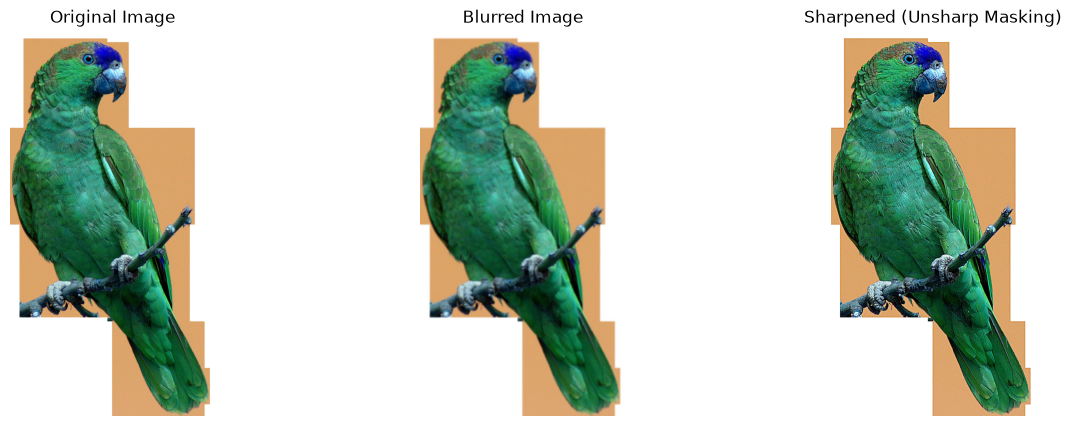

In [4]:
# Read the image
image = cv2.imread('images/Parrot.png')

if image is None:
    print("Error: unable to load image at images/Parrot.png")

image = cv2.imread('../images/Parrot.png')  # Convert from BGR to RGB

# Gaussian sigma
sigma = 2

# Parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")

plt.show()

**Observations:** the blurred copy loses fine detail, so the difference `image - blurred` contains mainly edges and texture. Adding that difference back (here with `amount = 1.5`) exaggerates edges, which is what makes the result look sharper; `np.clip` keeps values inside `[0, 1]`.

---
---

# Assessment

The three tasks below allow an image of your choice. As a **substitute** (not the lab's own picture), they use scikit-image's built-in `astronaut` image, so no external file is needed. To use your own picture instead, replace the first line of the next cell with `cv2.cvtColor(cv2.imread('images/your_image.png'), cv2.COLOR_BGR2RGB)`.

### Load the image

In [5]:
image_rgb = data.astronaut()  # substitute image (RGB, uint8)

print("image_rgb:", image_rgb.shape, image_rgb.dtype)

image_rgb: (512, 512, 3) uint8


### Task #1 — 7x7 box filter

A box filter replaces every pixel with the average of its 7x7 neighbourhood, so the kernel is a 7x7 matrix of `1/49`. `cv2.filter2D` performs the convolution.

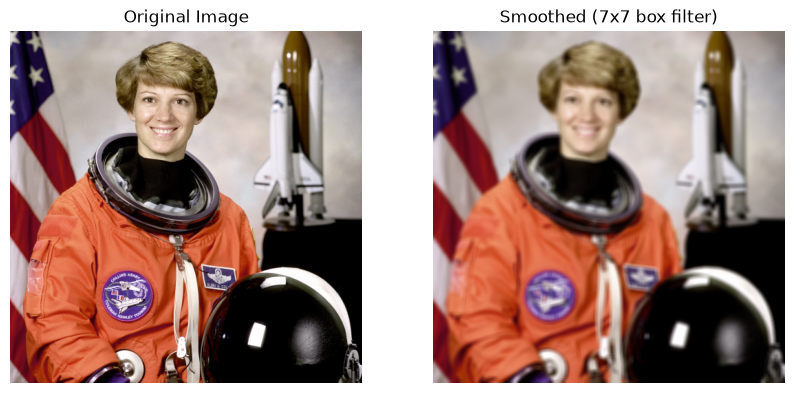

In [6]:
box_kernel = np.ones((7, 7), np.float32) / (7 * 7)
box_smoothed = cv2.filter2D(image_rgb, -1, box_kernel)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(box_smoothed)
ax[1].set_title("Smoothed (7x7 box filter)")
ax[1].axis("off")
plt.show()

### Task #2 — 5x5 and 21x21 Gaussian filters

`cv2.GaussianBlur` smooths with a Gaussian-weighted neighbourhood. With `sigmaX=0`, OpenCV derives sigma from the kernel size, so the larger kernel blurs more.

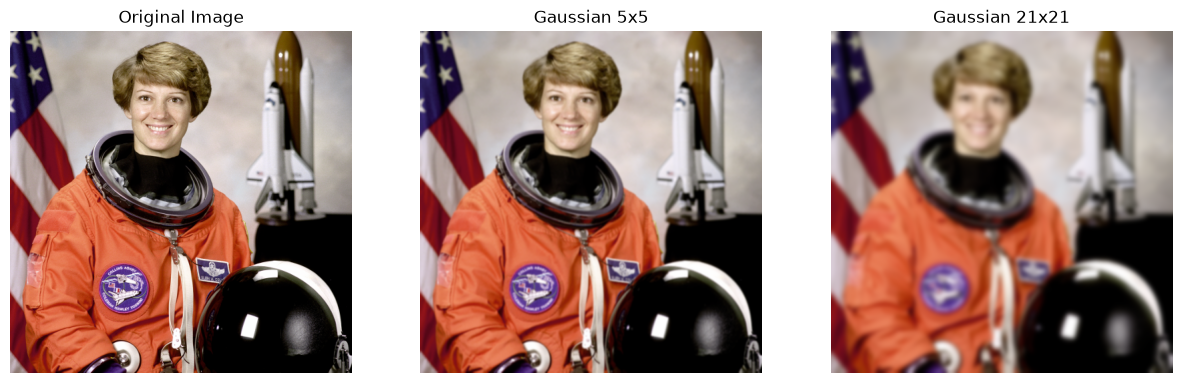

In [7]:
gauss_5 = cv2.GaussianBlur(image_rgb, (5, 5), 0)
gauss_21 = cv2.GaussianBlur(image_rgb, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(gauss_5)
ax[1].set_title("Gaussian 5x5")
ax[1].axis("off")
ax[2].imshow(gauss_21)
ax[2].set_title("Gaussian 21x21")
ax[2].axis("off")
plt.show()

### Task #3 — 3x3 Laplacian sharpening

Following the lab's steps: read the image, convert it to float32, apply `cv2.Laplacian` (3x3 kernel), then sharpen with `np.clip(image_float - laplacian, 0, 1)`. The Laplacian is computed on a grayscale version so it can be displayed as a single-channel image.

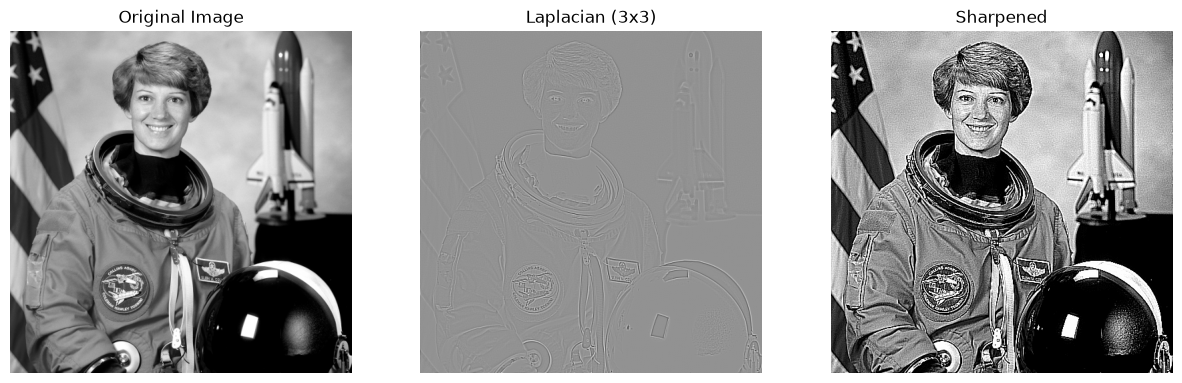

In [8]:
# Read the image (grayscale version of the substitute image)
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Convert image to float32 in [0, 1]
image_float = gray.astype(np.float32) / 255.0

# 3x3 Laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

# Sharpen: subtract the Laplacian (the kernel has a negative centre)
sharpened_lap = np.clip(image_float - laplacian, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_float, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(laplacian, cmap="gray")
ax[1].set_title("Laplacian (3x3)")
ax[1].axis("off")
ax[2].imshow(sharpened_lap, cmap="gray", vmin=0, vmax=1)
ax[2].set_title("Sharpened")
ax[2].axis("off")
plt.show()

**Observations:** the box and Gaussian filters both smooth the image, and a bigger kernel (7x7 box, 21x21 Gaussian) removes more fine detail than a smaller one (5x5 Gaussian). The Laplacian responds only at intensity changes (edges), and subtracting it from the original boosts those edges, giving a sharper image.

---
## Conclusion

This lab covered **smoothing** (box and Gaussian filters, which average neighbouring pixels and remove detail) and **sharpening** (unsharp masking and the Laplacian, which isolate edges and add them back to the original).



**End of notebook.**